In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import uniform, randint

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV


In [23]:
target_train = pd.read_parquet("target_train.parquet")
network_train = pd.read_parquet("network_train.parquet")
weather_train = pd.read_parquet("weather_train.parquet")
weather_test = pd.read_parquet("weather_test.parquet")
network_test = pd.read_parquet("network_test.parquet")

In [42]:


### functions already used for EDA

def flatten_weather_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = ["_".join([str(i) for i in col]) for col in df.columns]
    return df


def interpolate_weather(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_index()
    df = df.interpolate(method="time")
    df = df.ffill()
    return df


def aggregate_weather(df: pd.DataFrame) -> pd.DataFrame:
    ssrd_cols = [c for c in df.columns if c.endswith("ssrd")]
    tcc_cols  = [c for c in df.columns if c.endswith("tcc")]
    temp_cols = [c for c in df.columns if c.endswith("2t")]
    wind_cols = [c for c in df.columns if c.endswith("100ws")]

    flat = pd.DataFrame(index=df.index)
    flat["ssrd_mean"] = df[ssrd_cols].mean(axis=1)
    flat["ssrd_std"]  = df[ssrd_cols].std(axis=1)
    flat["tcc_mean"]  = df[tcc_cols].mean(axis=1)
    flat["tcc_std"]   = df[tcc_cols].std(axis=1)
    flat["temp_mean"] = df[temp_cols].mean(axis=1)
    flat["temp_std"] = df[temp_cols].std(axis=1)
    flat["wind_mean"] = df[wind_cols].mean(axis=1)
    flat["wind_std"]  = df[wind_cols].std(axis=1)

    return flat.bfill().ffill()


def prepare_weather(df: pd.DataFrame) -> pd.DataFrame:
    """Flatten multi-index columns, interpolate missing values, and aggregate to per-hour stats."""
    df = flatten_weather_columns(df)
    df = interpolate_weather(df)
    df = aggregate_weather(df)
    df = df.reset_index().rename(columns={df.index.name or "index": "ds"})
    return df


def add_lag_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["ssrd_lag1"]  = df["ssrd_mean"].shift(1)
    df["ssrd_lag24"] = df["ssrd_mean"].shift(24)
    return df


def add_rolling_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["ssrd_roll_3h"]     = df["ssrd_mean"].rolling(3).mean()
    df["ssrd_roll_24h"]    = df["ssrd_mean"].rolling(24).mean()
    df["tcc_roll_6h_std"]  = df["tcc_mean"].rolling(6).std()

    # Add new rolling features for tcc_mean, temp_mean, and wind_mean
    df["tcc_roll_3h_mean"] = df["tcc_mean"].rolling(3).mean()
    df["tcc_roll_24h_mean"] = df["tcc_mean"].rolling(24).mean()
    df["temp_roll_3h_mean"] = df["temp_mean"].rolling(3).mean()
    df["temp_roll_24h_mean"] = df["temp_mean"].rolling(24).mean()
    df["wind_roll_3h_mean"] = df["wind_mean"].rolling(3).mean()
    df["wind_roll_24h_mean"] = df["wind_mean"].rolling(24).mean()
    df["temp_roll_6h_std"]  = df["temp_mean"].rolling(6).std()
    df["wind_roll_6h_std"]  = df["wind_mean"].rolling(6).std()

    return df


def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    dt = pd.to_datetime(df["ds"])
    df["hour"]      = dt.dt.hour
    df["month"]     = dt.dt.month
    df["hour_sin"]  = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"]  = np.cos(2 * np.pi * df["hour"] / 24)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    return df


def add_solar_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["ssrd_norm"]       = df["ssrd_mean"] / df["ssrd_mean"].max()
    df["solar_potential"] = df["ssrd_norm"] * (1 - df["tcc_mean"])
    return df


def engineer_weather_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add lags, rolling stats, time encodings, and solar features, then drop NaN rows."""
    df = add_lag_features(df)
    df = add_rolling_features(df)
    df = add_time_features(df)



    df = add_solar_features(df)
    return df.dropna()
def prepare_solar_data(target_path: str, weather_path: str, network_path: str) -> pd.DataFrame:
    """Complete pipeline: load + preprocess weather + merge with targets and network features."""
    target_train = pd.read_parquet(target_path)
    weather_train = pd.read_parquet(weather_path)
    network_train = pd.read_parquet(network_path)

    # Interpolate and clip FR_solar_actual before merging
    target_train["FR_solar_actual"] = (
        target_train["FR_solar_actual"]
        .interpolate(method="time")
        .bfill()
        .ffill()
        .clip(lower=0)
    )

    weather_features = engineer_weather_features(prepare_weather(weather_train))

    # Merge with targets and network features
    solar_df = target_train[['FR_solar_actual']].join(weather_features, how='inner').join(network_train, how='inner')

    return solar_df

def prepare_wind_data(target_path: str, weather_path: str) -> pd.DataFrame:
    """Complete pipeline for wind."""
    target_train = pd.read_parquet(target_path)
    weather_train = pd.read_parquet(weather_path)

    weather_features = engineer_weather_features(prepare_weather(weather_train))

    wind_df = target_train[['FR_wind_actual']].join(weather_features)

    return wind_df

def prepare_load_data(target_path: str, weather_path: str, network_path: str) -> pd.DataFrame:
    """Complete pipeline for load (includes network features)."""
    target_train = pd.read_parquet(target_path)
    weather_train = pd.read_parquet(weather_path)
    network_train = pd.read_parquet(network_path)

    weather_features = engineer_weather_features(prepare_weather(weather_train))

    load_df = target_train[['FR_load_actual']].join(weather_features).join(network_train)

    return load_df
##for train test split
def split_data_chronologically(df: pd.DataFrame, test_size: float = 0.2):
    """
    Splits a DataFrame chronologically into training and validation sets,
    and separates features (X) from the target (y).

    Args:
        df (pd.DataFrame): The input DataFrame.
        test_size (float): The proportion of the dataset to include in the validation split.

    Returns:
        tuple: (X_train, y_train, X_valid, y_valid) as pandas DataFrames/Series.
    """
    # Calculate the split point
    split_point = int(len(df) * (1 - test_size))

    # Split the data chronologically
    train = df.iloc[:split_point]
    valid = df.iloc[split_point:]

    # Separate features (X) and target (y)
    X_train = train.drop('FR_solar_actual', axis=1)
    y_train = train['FR_solar_actual']
    X_valid = valid.drop('FR_solar_actual', axis=1)
    y_valid = valid['FR_solar_actual']

    print('Training set shape:', train.shape)
    print('Validation set shape:', valid.shape)

    return X_train, y_train, X_valid, y_valid

##for evaluation
def wmape(y_true, y_pred):
    """Weighted Mean Absolute Percentage Error"""
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

class TimeSeriesEvaluator:
    def compute_standard_metrics(self):
        return {
            'Target': self.target_name,
            'RMSE': np.sqrt(mean_squared_error(self.y_true, self.y_pred)),
            'MAE': mean_absolute_error(self.y_true, self.y_pred),
            'WMAPE': wmape(self.y_true, self.y_pred),
            'R²': r2_score(self.y_true, self.y_pred),
        }

In [25]:
weather_flat = prepare_weather(weather_train)
weather_flat.head()

,ds,ssrd_mean,ssrd_std,tcc_mean,tcc_std,temp_mean,temp_std,wind_mean,wind_std
0,2020-01-01 00:00:00+00:00,0.0,0.0,0.490648,0.425557,3.114028,3.679530,4.431250,2.351552
1,2020-01-01 01:00:00+00:00,0.0,0.0,0.499319,0.416623,2.807910,3.637566,4.399936,2.316953
2,2020-01-01 02:00:00+00:00,0.0,0.0,0.518816,0.414566,2.749704,3.592852,4.380681,2.291575
3,2020-01-01 03:00:00+00:00,0.0,0.0,0.534694,0.409608,2.656238,3.711994,4.475877,2.365991
4,2020-01-01 04:00:00+00:00,0.0,0.0,0.548571,0.407396,2.599818,3.779075,4.508040,2.380406


### Consolidated Weather Feature Engineering

Instead of manually adding lag, rolling, time, and solar features, we can use the `engineer_weather_features` function to automate this process. This function internally calls `add_lag_features`, `add_rolling_features`, `add_time_features`, and `add_solar_features`, and also handles dropping `NaN` rows resulting from these operations.

In [26]:
# Re-apply prepare_weather to get a clean DataFrame (with 'ds' as a column) as input for engineer_weather_features.
weather_flat = prepare_weather(weather_train)

# Now, apply the comprehensive feature engineering function
weather_flat = engineer_weather_features(weather_flat)

# Set 'ds' as the index for consistency with subsequent join operations, and remove the original 'ds' column.
weather_flat = weather_flat.set_index('ds')

print("Engineered weather_flat DataFrame head:")
display(weather_flat.head())
print("\nEngineered weather_flat DataFrame info:")
weather_flat.info()


Engineered weather_flat DataFrame head:


,ssrd_mean,ssrd_std,tcc_mean,tcc_std,temp_mean,temp_std,wind_mean,wind_std,ssrd_lag1,ssrd_lag24,...,temp_roll_6h_std,wind_roll_6h_std,hour,month,hour_sin,hour_cos,month_sin,month_cos,ssrd_norm,solar_potential
ds,,,,,,,,,,,,,,,,,,,,,
2020-01-02 00:00:00+00:00,0.0,0.0,0.591098,0.397544,4.024190,3.424526,3.861214,2.025915,0.0,0.0,...,0.148966,0.083488,0,1,0.000000,1.000000,0.5,0.866025,0.0,0.0
2020-01-02 01:00:00+00:00,0.0,0.0,0.626592,0.391434,3.880080,3.565624,4.081434,2.093134,0.0,0.0,...,0.102429,0.171253,1,1,0.258819,0.965926,0.5,0.866025,0.0,0.0
2020-01-02 02:00:00+00:00,0.0,0.0,0.647933,0.395149,3.885397,3.561708,4.182189,2.126657,0.0,0.0,...,0.076456,0.225824,2,1,0.500000,0.866025,0.5,0.866025,0.0,0.0
2020-01-02 03:00:00+00:00,0.0,0.0,0.652530,0.402927,3.899515,3.605973,4.303050,2.085833,0.0,0.0,...,0.059011,0.250485,3,1,0.707107,0.707107,0.5,0.866025,0.0,0.0
2020-01-02 04:00:00+00:00,0.0,0.0,0.651431,0.406992,3.928852,3.585760,4.358646,2.013896,0.0,0.0,...,0.054884,0.245929,4,1,0.866025,0.500000,0.5,0.866025,0.0,0.0



Engineered weather_flat DataFrame info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43825 entries, 2020-01-02 00:00:00+00:00 to 2025-01-01 00:00:00+00:00
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ssrd_mean           43825 non-null  float32
 1   ssrd_std            43825 non-null  float32
 2   tcc_mean            43825 non-null  float32
 3   tcc_std             43825 non-null  float32
 4   temp_mean           43825 non-null  float32
 5   temp_std            43825 non-null  float32
 6   wind_mean           43825 non-null  float32
 7   wind_std            43825 non-null  float32
 8   ssrd_lag1           43825 non-null  float32
 9   ssrd_lag24          43825 non-null  float32
 10  ssrd_roll_3h        43825 non-null  float64
 11  ssrd_roll_24h       43825 non-null  float64
 12  tcc_roll_6h_std     43825 non-null  float64
 13  tcc_roll_3h_mean    43825 non-null  float64
 14  tcc_roll_24h_m

In [27]:
   # Drop original 'hour' and 'month' columns after creating cyclical features
weather_flat = weather_flat.drop(columns=['hour', 'month'])

As showed during EDA it is necessary to compute also the logarithm of ssrd

In [28]:
weather_flat ['ssrd_log'] = np.log1p(weather_flat ['ssrd_mean'])
weather_flat ['ssrd_std_log'] = np.log1p(weather_flat ['ssrd_std'])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [29]:
weather_flat = weather_flat.drop(columns=['ssrd_mean', 'ssrd_std'])

In [30]:
weather_flat.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43825 entries, 2020-01-02 00:00:00+00:00 to 2025-01-01 00:00:00+00:00
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tcc_mean            43825 non-null  float32
 1   tcc_std             43825 non-null  float32
 2   temp_mean           43825 non-null  float32
 3   temp_std            43825 non-null  float32
 4   wind_mean           43825 non-null  float32
 5   wind_std            43825 non-null  float32
 6   ssrd_lag1           43825 non-null  float32
 7   ssrd_lag24          43825 non-null  float32
 8   ssrd_roll_3h        43825 non-null  float64
 9   ssrd_roll_24h       43825 non-null  float64
 10  tcc_roll_6h_std     43825 non-null  float64
 11  tcc_roll_3h_mean    43825 non-null  float64
 12  tcc_roll_24h_mean   43825 non-null  float64
 13  temp_roll_3h_mean   43825 non-null  float64
 14  temp_roll_24h_mean  43825 non-null  float64
 15  wind_r

In [31]:
network_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43849 entries, 2020-01-01 00:00:00+00:00 to 2025-01-01 00:00:00+00:00
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EEX_CARBON               43849 non-null  float32
 1   EEX_COAL                 43849 non-null  float32
 2   EEX_GAS_PEG              43849 non-null  float32
 3   FR_capacity_solar        43849 non-null  float32
 4   FR_capacity_wind         43849 non-null  float32
 5   FR_availability_coal     43849 non-null  float32
 6   FR_availability_gas      43849 non-null  float32
 7   FR_availability_hydro    43849 non-null  float32
 8   FR_availability_nuclear  43849 non-null  float32
dtypes: float32(9)
memory usage: 1.8 MB


These 24 missing rows in weather_flat come from the lag and rolling features  created. These features require 24 hours of history, so the first 24 timestamps cannot be computed and were dropped.

In [32]:
X = weather_flat.join(network_train, how="inner")

In [33]:
target_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43849 entries, 2020-01-01 00:00:00+00:00 to 2025-01-01 00:00:00+00:00
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   FR_load_actual   43785 non-null  float32
 1   FR_price_actual  43849 non-null  float32
 2   FR_solar_actual  43105 non-null  float32
 3   FR_wind_actual   43705 non-null  float32
dtypes: float32(4)
memory usage: 1.0 MB


FR_solar_actual  43105 indicate that there are 744 rows missing. I will interpolate the missing values

In [34]:


target_train["FR_solar_actual"] = (
    target_train["FR_solar_actual"]
    .interpolate(method="time")
    .bfill()
    .ffill()
    .clip(lower=0)
)

y=target_train[["FR_solar_actual"]]

In [35]:
solar_df=X.join(y, how="inner")

Train Test Split

In [38]:
X_train, y_train, X_valid, y_valid = split_data_chronologically(solar_df, test_size=0.2)

print('\nX_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_valid shape:', X_valid.shape)
print('y_valid shape:', y_valid.shape)

Training set shape: (35060, 37)
Validation set shape: (8765, 37)

X_train shape: (35060, 36)
y_train shape: (35060,)
X_valid shape: (8765, 36)
y_valid shape: (8765,)


#ML Models

## 1. LGBM

In [ ]:
model_1 = LGBMRegressor(
    objective="regression",
    n_estimators=500,           # ← Reduced from 1000
    learning_rate=0.05,
    num_leaves=32,              # ← Reduced from 64
    subsample=0.7,              # ← Reduced from 0.8
    colsample_bytree=0.7,       # ← Reduced from 0.8
    min_child_samples=20,       # ← ADD THIS (prevent overfitting)
    reg_alpha=0.1,              # ← ADD THIS (L1 regularization)
    reg_lambda=0.1,             # ← ADD THIS (L2 regularization)
    random_state=42
)

In [62]:


# model_1 = LGBMRegressor(
#     objective="regression",
#     n_estimators=1000,
#     learning_rate=0.05,
#     num_leaves=64,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42
# )
model_1 = LGBMRegressor(
    objective="regression",
    n_estimators=500,
    num_leaves=32,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_samples=20,
    random_state=42)
model_1.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="rmse",
    callbacks=[]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002733 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8003
[LightGBM] [Info] Number of data points in the train set: 35060, number of used features: 36
[LightGBM] [Info] Start training from score 1880.260090


LGBMRegressor(colsample_bytree=0.7, n_estimators=500, num_leaves=32,
              objective='regression', random_state=42, subsample=0.7)

In [63]:
y_pred_train_lgbm = model_1.predict(X_train)

mae_train_lgbm = mean_absolute_error(y_train, y_pred_train_lgbm)
rmse_train_lgbm = np.sqrt(mean_squared_error(y_train, y_pred_train_lgbm))
r2_train_lgbm = r2_score(y_train, y_pred_train_lgbm)
wmape_train_lgbm = np.sum(np.abs(y_train - y_pred_train_lgbm)) / np.sum(y_train)

print("LightGBM Model Performance on Training Data:")
print(f"MAE: {mae_train_lgbm}")
print(f"RMSE: {rmse_train_lgbm}")
print(f"WMAPE: {wmape_train_lgbm:.4f}")
print(f"R²: {r2_train_lgbm}")


LightGBM Model Performance on Training Data:
MAE: 78.94637618545059
RMSE: 137.46738846581374
WMAPE: 0.0420
R²: 0.9973519647155487


In [64]:
y_pred = model_1.predict(X_valid)

In [65]:
y_pred = model_1.predict(X_valid)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
mae = mean_absolute_error(y_valid, y_pred)
wmape = np.sum(np.abs(y_valid - y_pred)) / np.sum(y_valid)
r2 = r2_score(y_valid, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"WMAPE: {wmape:.4f}")
print(f"R²: {r2}")

RMSE: 1493.03
MAE: 833.44
WMAPE: 0.3373
R²: 0.8237049631404941


Overfitting!

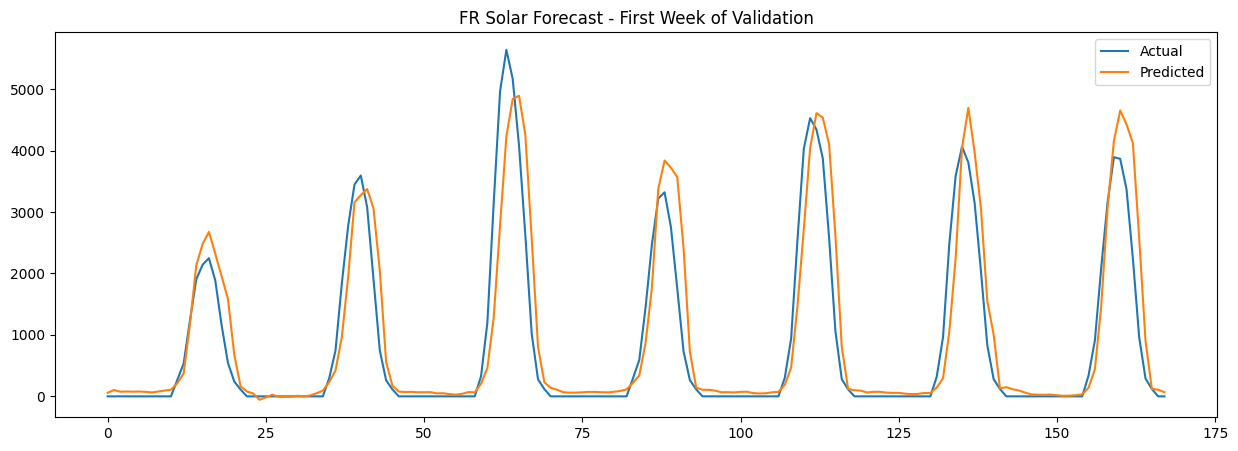

In [66]:


plt.figure(figsize=(15, 5))
plt.plot(y_valid.iloc[:168].values, label="Actual")
plt.plot(y_pred[:168], label="Predicted")
plt.legend()
plt.title("FR Solar Forecast - First Week of Validation")
plt.show()

In [67]:
##check what are the important features

fi = pd.Series(
    model_1.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(fi.head(20))

FR_capacity_solar          715
ssrd_roll_24h              625
wind_roll_24h_mean         623
ssrd_std_log               619
temp_roll_24h_mean         600
FR_availability_nuclear    587
ssrd_lag24                 586
tcc_roll_24h_mean          585
FR_availability_hydro      574
ssrd_norm                  545
FR_availability_gas        530
EEX_CARBON                 521
EEX_COAL                   496
temp_roll_6h_std           486
solar_potential            474
hour_sin                   454
wind_std                   442
tcc_std                    425
tcc_roll_3h_mean           421
temp_std                   406
dtype: int32


## 2. XGBoost Model

In [68]:


model_2 = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    subsample=0.6,
    colsample_bytree=0.6,
    random_state=42,
    verbosity=0)

model_2.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [70]:
y_pred_train_xgb = model_2.predict(X_train)

mae_train_xgb = mean_absolute_error(y_train, y_pred_train_xgb)
rmse_train_xgb = np.sqrt(mean_squared_error(y_train, y_pred_train_xgb))
r2_train_xgb = r2_score(y_train, y_pred_train_xgb)
wmape_train_xgb = np.sum(np.abs(y_train - y_pred_train_xgb)) / np.sum(y_train)

print("XGBoost Model Performance on Training Data:")
print(f"MAE: {mae_train_xgb}")
print(f"RMSE: {rmse_train_xgb}")
print(f"WMAPE: {wmape:.4f}")
print(f"R²: {r2_train_xgb}")

XGBoost Model Performance on Training Data:
MAE: 187.70094299316406
RMSE: 336.47660812083205
WMAPE: 0.3373
R²: 0.9841352105140686


In [71]:
y_pred_xgb = model_2.predict(X_valid)

In [72]:


mae_xgb = mean_absolute_error(y_valid, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_valid, y_pred_xgb))
r2_xgb = r2_score(y_valid, y_pred_xgb)
wmape = np.sum(np.abs(y_valid - y_pred)) / np.sum(y_valid)

print("XGBoost Model Performance:")
print(f"MAE: {mae_xgb}")
print(f"RMSE: {rmse_xgb}")

print(f"WMAPE: {wmape:.4f}")
print(f"R²: {r2_xgb}")

XGBoost Model Performance:
MAE: 802.3134155273438
RMSE: 1456.4306540305995
WMAPE: 0.3373
R²: 0.8322428464889526


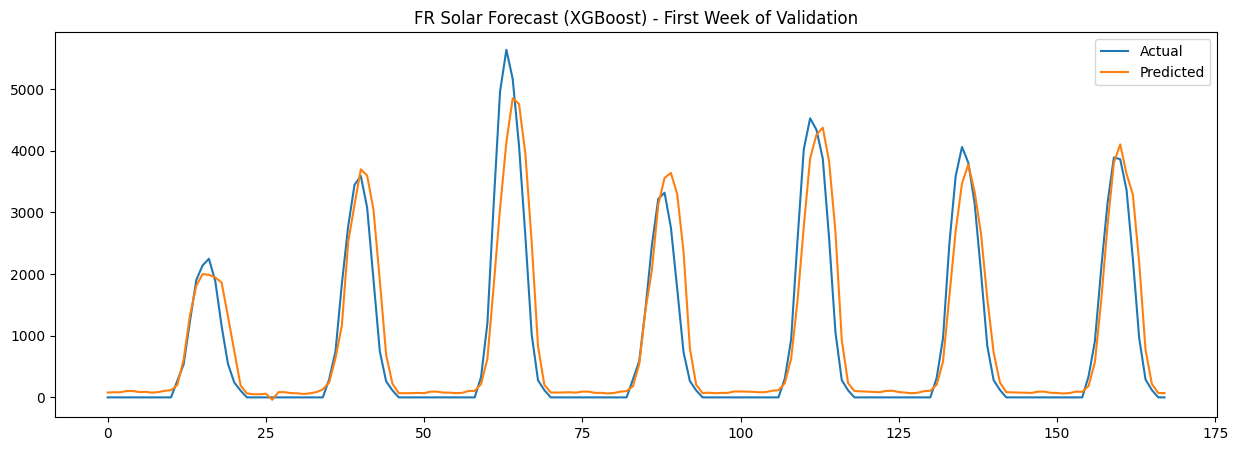

In [73]:
plt.figure(figsize=(15, 5))
plt.plot(y_valid.iloc[:168].values, label="Actual")
plt.plot(y_pred_xgb[:168], label="Predicted")
plt.legend()
plt.title("FR Solar Forecast (XGBoost) - First Week of Validation")
plt.show()

In [74]:
fi_xgb = pd.Series(
    model_2.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("XGBoost Feature Importances (Top 20):")
print(fi_xgb.head(20))

XGBoost Feature Importances (Top 20):
ssrd_log                   0.342252
ssrd_norm                  0.254524
ssrd_lag24                 0.111921
hour_cos                   0.079568
temp_roll_6h_std           0.038793
solar_potential            0.030031
hour_sin                   0.029080
FR_capacity_solar          0.026074
ssrd_std_log               0.015464
FR_capacity_wind           0.011626
ssrd_lag1                  0.010411
ssrd_roll_3h               0.009216
EEX_GAS_PEG                0.004779
EEX_CARBON                 0.003209
ssrd_roll_24h              0.002868
tcc_roll_24h_mean          0.002802
tcc_mean                   0.002426
tcc_roll_3h_mean           0.002121
EEX_COAL                   0.002117
FR_availability_nuclear    0.001916
dtype: float32


Still overfitting!

## Hyperparameter Tuning for XGBoost using RandomizedSearchCV

In [84]:


param_dist = {
    'n_estimators': randint(200, 600),
    'learning_rate': uniform(0.01, 0.05),
    'max_depth': randint(3, 6),
    'subsample': uniform(0.5, 0.35),
    'colsample_bytree': uniform(0.5, 0.35),
    'reg_alpha': uniform(0.5, 2),
    'reg_lambda': uniform(0.5, 2),
    'min_child_weight': randint(8, 20),
}
#Crossvalidation
tscv = TimeSeriesSplit(n_splits=3)

random_search = RandomizedSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=42, tree_method='hist'),
    param_distributions=param_dist,
    n_iter=50,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_
tuned_rmse = np.sqrt(mean_squared_error(y_valid, best_model.predict(X_valid)))

print("\n" + "="*60)
print("RESULTS")
print("="*60)

print(f"Tuned RMSE:    {tuned_rmse:.2f} MW")

print(f"\nBest parameters: {random_search.best_params_}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits

RESULTS
Tuned RMSE:    1483.85 MW

Best parameters: {'colsample_bytree': np.float64(0.7662975551270961), 'learning_rate': np.float64(0.017338690734452197), 'max_depth': 5, 'min_child_weight': 17, 'n_estimators': 418, 'reg_alpha': np.float64(1.5812096432150535), 'reg_lambda': np.float64(0.6268883289510656), 'subsample': np.float64(0.6220001696016846)}


After finding the best parameters,I then train a new XGBoost model with these optimal settings and evaluate its performance on the validation set.

In [85]:
# Train a new model with the best parameters
best_xgb_model = random_search.best_estimator_

# Make predictions on the validation set
y_pred_tuned_xgb = best_xgb_model.predict(X_valid)

# Evaluate the tuned model
mae_tuned_xgb = mean_absolute_error(y_valid, y_pred_tuned_xgb)
rmse_tuned_xgb = np.sqrt(mean_squared_error(y_valid, y_pred_tuned_xgb))
r2_tuned_xgb = r2_score(y_valid, y_pred_tuned_xgb)

print("Tuned XGBoost Model Performance:")
print(f"MAE: {mae_tuned_xgb}")
print(f"RMSE: {rmse_tuned_xgb}")
print(f"R²: {r2_tuned_xgb}")

Tuned XGBoost Model Performance:
MAE: 834.9249877929688
RMSE: 1483.8527554983345
R²: 0.8258662223815918


In [86]:
y_pred_train_xgb = best_xgb_model.predict(X_train)

mae_train_xgb = mean_absolute_error(y_train, y_pred_train_xgb)
rmse_train_xgb = np.sqrt(mean_squared_error(y_train, y_pred_train_xgb))
r2_train_xgb = r2_score(y_train, y_pred_train_xgb)

print("\nTuned XGBoost Model Performance on Training Data:")
print(f"MAE: {mae_train_xgb}")
print(f"RMSE: {rmse_train_xgb}")
print(f"R²: {r2_train_xgb}")


Tuned XGBoost Model Performance on Training Data:
MAE: 179.59063720703125
RMSE: 343.84524816768953
R²: 0.9834327697753906


Still overfitting! The hyperparameter tuning did not help

#Cross validation

Yes, time-series cross-validation will help you obtain more robust validation scores and better hyperparameters. It does not directly prevent overfitting, but it is one of the best ways to detect and reduce it through better model selection.

In [89]:


tscv = TimeSeriesSplit(n_splits=3)

In [90]:
X_cv = solar_df.drop('FR_solar_actual', axis=1)
y_cv = solar_df['FR_solar_actual']

In [91]:
rmse_scorer = make_scorer(
    lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
    greater_is_better=False
)

scores = cross_val_score(
    model_1,
    X_cv,
    y_cv,
    cv=tscv,
    scoring=rmse_scorer
)

print("RMSE per fold:", -scores)
print("Average RMSE:", -scores.mean())

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000883 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7916
[LightGBM] [Info] Number of data points in the train set: 10957, number of used features: 36
[LightGBM] [Info] Start training from score 1352.239710
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001899 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7963
[LightGBM] [Info] Number of data points in the train set: 21913, number of used features: 36
[LightGBM] [Info] Start training from score 1596.920435
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002576 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not

In [92]:
r2_scorer = make_scorer(r2_score)

r2_scores = cross_val_score(
    model_1,
    X_cv,
    y_cv,
    cv=tscv,
    scoring=r2_scorer
)

print("R-squared per fold:", r2_scores)
print("Average R-squared:", r2_scores.mean())

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000880 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7916
[LightGBM] [Info] Number of data points in the train set: 10957, number of used features: 36
[LightGBM] [Info] Start training from score 1352.239710
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009369 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7963
[LightGBM] [Info] Number of data points in the train set: 21913, number of used features: 36
[LightGBM] [Info] Start training from score 1596.920435
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002578 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] To